<a href="https://colab.research.google.com/github/shraddhas-20/CityAQI-Classification-Deep-Learning/blob/main/CityAQI(ClassificationDeepLearning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [380]:
'''from google.colab import files
uploaded = files.upload()'''

'from google.colab import files\nuploaded = files.upload()'

In [381]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [382]:
df = pd.read_csv('city_day.csv')

In [383]:
df

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [384]:
df['City'].unique()

array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], dtype=object)

In [385]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [386]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [387]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [388]:
df = df.fillna(df.mean(numeric_only=True))

In [389]:
df['AQI_Bucket'] = df['AQI_Bucket'].fillna(df['AQI_Bucket'].mode()[0])

In [390]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


In [391]:
df[df['AQI'] > 500].shape

(543, 16)

In [392]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       29531 non-null  float64
 3   PM10        29531 non-null  float64
 4   NO          29531 non-null  float64
 5   NO2         29531 non-null  float64
 6   NOx         29531 non-null  float64
 7   NH3         29531 non-null  float64
 8   CO          29531 non-null  float64
 9   SO2         29531 non-null  float64
 10  O3          29531 non-null  float64
 11  Benzene     29531 non-null  float64
 12  Toluene     29531 non-null  float64
 13  Xylene      29531 non-null  float64
 14  AQI         29531 non-null  float64
 15  AQI_Bucket  29531 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [393]:
df.shape

(29531, 16)

## *One-Hot Encoding of Cities*

In [394]:
df = pd.get_dummies(df, columns = ['City'])

In [395]:
df.columns

Index(['Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'City_Ahmedabad',
       'City_Aizawl', 'City_Amaravati', 'City_Amritsar', 'City_Bengaluru',
       'City_Bhopal', 'City_Brajrajnagar', 'City_Chandigarh', 'City_Chennai',
       'City_Coimbatore', 'City_Delhi', 'City_Ernakulam', 'City_Gurugram',
       'City_Guwahati', 'City_Hyderabad', 'City_Jaipur', 'City_Jorapokhar',
       'City_Kochi', 'City_Kolkata', 'City_Lucknow', 'City_Mumbai',
       'City_Patna', 'City_Shillong', 'City_Talcher',
       'City_Thiruvananthapuram', 'City_Visakhapatnam'],
      dtype='object')

### *Grouping*

In [396]:
pollutants = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene']

Text(0.5, 1.0, 'Pollutant Correlation Heatmap')

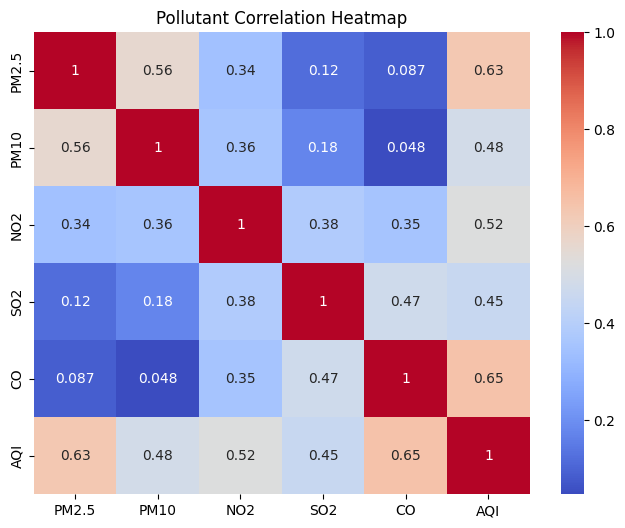

In [397]:
pollutants = ['PM2.5','PM10','NO2','SO2','CO','AQI']

plt.figure(figsize=(8,6))
sns.heatmap(df[pollutants].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Pollutant Correlation Heatmap")


## *AQI categories*

In [398]:
bins = [0, 50, 100, 200, 300, 400, 5000]

In [399]:
labels = ['Good','Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']

In [400]:
df['AQI_Category'] = pd.cut(df['AQI'],bins=bins,labels=labels,include_lowest=True)

In [401]:
df[['AQI', 'AQI_Category']].head()

,AQI,AQI_Category
0,166.463581,Moderate
1,166.463581,Moderate
2,166.463581,Moderate
3,166.463581,Moderate
4,166.463581,Moderate


## *Encoding Target Variable*

In [402]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['AQI_Category_Encoded'] = le.fit_transform(df['AQI_Category'])

In [425]:
X = X.astype('float32')


# *Scaling*

In [403]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [404]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df.drop( ['AQI', 'AQI_Category', 'AQI_Category_Encoded', 'Date', 'AQI_Bucket'],axis=1)

y = df['AQI_Category_Encoded']

## *Train - test- split*

In [405]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

# ***Neural Network***

In [406]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(38,)), #define input shape
    Dense(128, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(6, activation='softmax')
])

In [407]:
model.compile(
    loss='sparse_categorical_crossentropy', #sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

In [408]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 128)            │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,750 (38.09 KB)

 Trainable params: 9,750 (38.09 KB)

 Non-trainable params: 0 (0.00 B)

In [409]:
model.fit(  X_train, y_train, epochs=20, batch_size=256,validation_split=0.2)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4619 - loss: 1.7513 - val_accuracy: 0.5257 - val_loss: 1.3613
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5450 - loss: 1.2385 - val_accuracy: 0.6066 - val_loss: 1.0961
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5765 - loss: 1.1394 - val_accuracy: 0.6188 - val_loss: 1.0231
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5986 - loss: 1.0521 - val_accuracy: 0.6326 - val_loss: 1.0321
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6168 - loss: 0.9979 - val_accuracy: 0.6425 - val_loss: 0.9260
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6323 - loss: 0.9489 - val_accuracy: 0.6726 - val_loss: 0.8709
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6462 - loss: 0.9053 - val_accuracy: 0.6722 - val_loss: 0.8499
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6593 - loss: 0.8658 - val_accuracy: 0.6320 - val_loss:

In [410]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)


In [413]:
from sklearn.metrics import accuracy_score


accuracy_score(y_test, y_pred)

0.8215676316234976

In [414]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.61      0.69       237
           1       0.85      0.89      0.87      2763
           2       0.69      0.58      0.63       553
           3       0.83      0.84      0.83      1611
           4       0.86      0.75      0.81       272
           5       0.74      0.77      0.75       471

    accuracy                           0.82      5907
   macro avg       0.80      0.74      0.76      5907
weighted avg       0.82      0.82      0.82      5907



In [418]:
X.dtypes

,0
PM2.5,float64
PM10,float64
NO,float64
NO2,float64
NOx,float64
NH3,float64
CO,float64
SO2,float64
O3,float64
Benzene,float64
